# 🎓 Intelligent Timetable Generator with Genetic Algorithm

**A production-grade, end-to-end timetable automation system** using a custom Genetic Algorithm,  
SQLite (free, zero-config), Flask REST API, and a Gradio UI — all runnable in one notebook.

---

## 📐 Project Architecture

```
┌─────────────────────────────────────────────────────────────────┐
│                    TIMETABLE GENERATOR SYSTEM                   │
│                                                                  │
│  Phase 1: Environment Setup & Dependencies                      │
│  Phase 2: Database Layer  (SQLite — no server needed)           │
│  Phase 3: Core Algorithm  (Genetic Algorithm Engine)            │
│  Phase 4: Service Layer   (Business Logic & Orchestration)      │
│  Phase 5: Flask REST API  (Auth + CRUD + Generation endpoints)  │
│  Phase 6: Gradio UI       (Interactive demo interface)          │
│  Phase 7: Testing & Demo  (End-to-end validation)               │
└─────────────────────────────────────────────────────────────────┘
```

### Tech Stack
| Layer | Technology |
|-------|------------|
| Algorithm | Custom Genetic Algorithm (Python) |
| Database | SQLite (via `sqlite3` — free, embedded) |
| Backend API | Flask + Flask-Login + Werkzeug |
| Frontend | HTML/CSS/JS (Jinja2 templates) |
| Interactive UI | Gradio |
| Notebook | Jupyter / Google Colab |


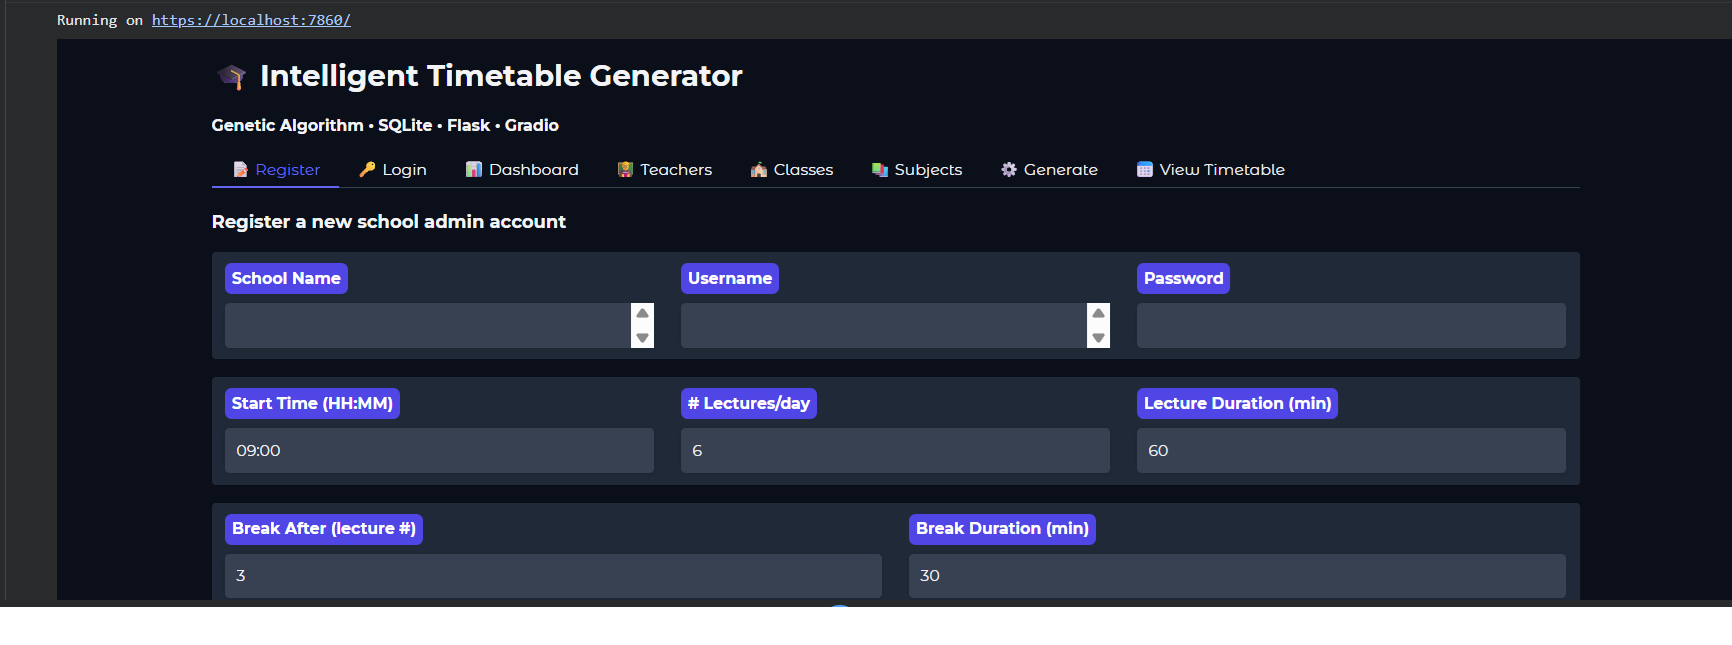

In [14]:
from IPython.display import Image, display

display(Image('/content/TT OUTPUT.png'))

---
## Phase 1: Environment Setup & Dependencies

Install all required packages. SQLite is built into Python — no external database server needed.


In [1]:
# ──────────────────────────────────────────────────────────────────
# PHASE 1: Install dependencies
# SQLite is part of Python stdlib — no pip install needed for DB.
# Flask serves the REST API; Gradio provides the interactive UI.
# ──────────────────────────────────────────────────────────────────
import subprocess, sys

packages = [
    'flask',
    'flask-login',
    'werkzeug',
    'gradio',
    'pandas',
    'requests',
    'python-dotenv',
    'tabulate',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('✅ All dependencies installed successfully.')


✅ All dependencies installed successfully.


In [2]:
# ──────────────────────────────────────────────────────────────────
# Standard library and third-party imports used throughout the project
# ──────────────────────────────────────────────────────────────────
import os
import sys
import json
import random
import sqlite3
import logging
import threading
import time as time_module
from datetime import datetime, timedelta
from pathlib import Path
from functools import wraps

import pandas as pd
from tabulate import tabulate

# Configure module-level logger so every phase can emit structured logs
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(name)s: %(message)s',
    datefmt='%H:%M:%S'
)
logger = logging.getLogger('timetable_generator')

# ── Project root path (notebook working directory)
PROJECT_ROOT = Path('.').resolve()
DB_PATH = PROJECT_ROOT / 'timetable.db'

print(f'✅ Imports loaded. Project root: {PROJECT_ROOT}')
print(f'   Database will be at: {DB_PATH}')


✅ Imports loaded. Project root: /content
   Database will be at: /content/timetable.db


---
## Phase 2: Database Layer (SQLite)

We replace MySQL with **SQLite** — zero configuration, no server, runs anywhere (local/Colab/cloud).
The schema mirrors the original MySQL design exactly, adapted for SQLite syntax.

### Schema Overview
```
schools ──< course
         ──< class ──< subject ──< timetable
         ──< teacher
         ──< room
timeslot ──< timetable
          ──< allocated_timeslots
          ──< practical
```


In [3]:
# ──────────────────────────────────────────────────────────────────
# DATABASE MODULE
# Provides connection management and all CRUD helpers for SQLite.
# SQLite is used instead of MySQL for portability — the schema and
# query logic are otherwise identical to the original design.
# ──────────────────────────────────────────────────────────────────

def get_db_connection():
    """
    Open a new SQLite connection.
    row_factory enables column-name access (dict-like rows).
    """
    conn = sqlite3.connect(str(DB_PATH))
    conn.row_factory = sqlite3.Row   # access columns by name, e.g. row['school_id']
    conn.execute('PRAGMA foreign_keys = ON')  # enforce FK constraints
    return conn


def init_database():
    """
    Create all tables if they do not already exist.
    Safe to call multiple times — uses IF NOT EXISTS guards.
    """
    schema_sql = '''
    -- ── Schools: one row per institution / admin account ──────────
    CREATE TABLE IF NOT EXISTS schools (
        school_id        INTEGER PRIMARY KEY AUTOINCREMENT,
        school_name      TEXT    NOT NULL,
        username         TEXT    NOT NULL UNIQUE,
        password_hash    TEXT    NOT NULL,
        start_time       TEXT,          -- HH:MM
        end_time         TEXT,          -- HH:MM
        lecture_duration INTEGER,       -- minutes per slot
        break_start_time TEXT,          -- HH:MM  (NULL if no break)
        break_duration   INTEGER DEFAULT 0
    );

    -- ── Course: programme of study (e.g. B.Tech CS) ───────────────
    CREATE TABLE IF NOT EXISTS course (
        course_id   INTEGER PRIMARY KEY AUTOINCREMENT,
        course_name TEXT    NOT NULL,
        school_id   INTEGER NOT NULL REFERENCES schools(school_id) ON DELETE CASCADE
    );

    -- ── Class: a student division / section ───────────────────────
    CREATE TABLE IF NOT EXISTS class (
        class_id   INTEGER PRIMARY KEY AUTOINCREMENT,
        class_name TEXT    NOT NULL,
        school_id  INTEGER NOT NULL REFERENCES schools(school_id) ON DELETE CASCADE
    );

    -- ── Room: physical space (lecture hall / lab) ─────────────────
    CREATE TABLE IF NOT EXISTS room (
        room_id    INTEGER PRIMARY KEY AUTOINCREMENT,
        room_name  TEXT    NOT NULL,
        room_type  TEXT    NOT NULL CHECK(room_type IN ('practical','lecture')),
        school_id  INTEGER NOT NULL REFERENCES schools(school_id) ON DELETE CASCADE
    );

    -- ── Teacher: faculty members ──────────────────────────────────
    CREATE TABLE IF NOT EXISTS teacher (
        teacher_id   INTEGER PRIMARY KEY AUTOINCREMENT,
        teacher_name TEXT    NOT NULL,
        school_id    INTEGER NOT NULL REFERENCES schools(school_id) ON DELETE CASCADE
    );

    -- ── Timeslot: global registry of time slots ───────────────────
    CREATE TABLE IF NOT EXISTS timeslot (
        time_id       INTEGER PRIMARY KEY AUTOINCREMENT,
        timeslot      TEXT    NOT NULL UNIQUE,  -- HH:MM:SS
        type_of_class TEXT    NOT NULL CHECK(type_of_class IN ('lecture','practical'))
    );

    -- ── Subject: course offered to a class ───────────────────────
    CREATE TABLE IF NOT EXISTS subject (
        subject_id   INTEGER PRIMARY KEY AUTOINCREMENT,
        subject_name TEXT    NOT NULL,
        class_id     INTEGER NOT NULL REFERENCES class(class_id),
        course_id    INTEGER NOT NULL REFERENCES course(course_id),
        teacher_id   INTEGER NOT NULL REFERENCES teacher(teacher_id),
        semester     INTEGER NOT NULL,
        credits      INTEGER DEFAULT 4,
        school_id    INTEGER NOT NULL REFERENCES schools(school_id) ON DELETE CASCADE
    );

    -- ── Timetable: generated schedule entries ────────────────────
    CREATE TABLE IF NOT EXISTS timetable (
        timetable_id INTEGER PRIMARY KEY AUTOINCREMENT,
        teacher_id   INTEGER NOT NULL REFERENCES teacher(teacher_id),
        subject_id   INTEGER NOT NULL REFERENCES subject(subject_id),
        class_id     INTEGER NOT NULL REFERENCES class(class_id),
        course_id    INTEGER NOT NULL REFERENCES course(course_id),
        time_id      INTEGER NOT NULL REFERENCES timeslot(time_id),
        day          TEXT,
        school_id    INTEGER NOT NULL REFERENCES schools(school_id) ON DELETE CASCADE
    );

    -- ── Allocated Timeslots: teacher-level busy-slot registry ─────
    CREATE TABLE IF NOT EXISTS allocated_timeslots (
        allocation_id INTEGER PRIMARY KEY AUTOINCREMENT,
        teacher_id    INTEGER NOT NULL REFERENCES teacher(teacher_id),
        subject_id    INTEGER NOT NULL REFERENCES subject(subject_id),
        time_id       INTEGER NOT NULL REFERENCES timeslot(time_id),
        school_id     INTEGER NOT NULL REFERENCES schools(school_id) ON DELETE CASCADE
    );

    -- ── Practical: lab session bookings ─────────────────────────
    CREATE TABLE IF NOT EXISTS practical (
        practical_id   INTEGER PRIMARY KEY AUTOINCREMENT,
        practical_name TEXT    NOT NULL,
        time_id        INTEGER NOT NULL REFERENCES timeslot(time_id),
        room_id        INTEGER NOT NULL REFERENCES room(room_id),
        class_id       INTEGER NOT NULL REFERENCES class(class_id),
        school_id      INTEGER NOT NULL REFERENCES schools(school_id) ON DELETE CASCADE
    );
    '''

    conn = get_db_connection()
    conn.executescript(schema_sql)
    conn.commit()
    conn.close()
    logger.info('Database initialised at %s', DB_PATH)


# ── Initialise DB immediately when this cell runs ─────────────────
init_database()
print('✅ Database schema created / verified.')


✅ Database schema created / verified.


In [4]:
# ──────────────────────────────────────────────────────────────────
# DATABASE HELPERS
# High-level query helpers consumed by the service and route layers.
# Each function opens its own connection and closes it on return,
# keeping resource management simple and explicit.
# ──────────────────────────────────────────────────────────────────

def db_fetch_subjects_and_timeslots(class_name, semester, school_id):
    """
    Return (subjects_list, timeslots_list) for a given class/semester.
    Used by the generation pipeline to prepare algorithm input.
    """
    conn = get_db_connection()
    cur = conn.cursor()

    cur.execute(
        'SELECT class_id FROM class WHERE class_name=? AND school_id=?',
        (class_name, school_id)
    )
    row = cur.fetchone()
    if not row:
        conn.close()
        return [], []

    class_id = row['class_id']
    cur.execute(
        'SELECT subject_name FROM subject WHERE class_id=? AND semester=? AND school_id=?',
        (class_id, semester, school_id)
    )
    subjects = [r['subject_name'] for r in cur.fetchall()]

    cur.execute('SELECT timeslot FROM timeslot ORDER BY timeslot')
    timeslots = [r['timeslot'] for r in cur.fetchall()]

    conn.close()
    return subjects, timeslots


def db_get_timetable_by_class(class_name, semester, school_id):
    """
    Fetch persisted timetable for a class/semester.
    Returns ({day_timeslot: subject}, [timeslots]).
    """
    conn = get_db_connection()
    cur = conn.cursor()

    cur.execute(
        'SELECT class_id FROM class WHERE class_name=? AND school_id=?',
        (class_name, school_id)
    )
    row = cur.fetchone()
    if not row:
        conn.close()
        return {}, []

    class_id = row['class_id']
    cur.execute(
        '''
        SELECT s.subject_name, t.day, ts.timeslot
        FROM timetable t
        JOIN subject  s  ON t.subject_id = s.subject_id
        JOIN timeslot ts ON t.time_id    = ts.time_id
        WHERE t.class_id=? AND s.semester=? AND t.school_id=?
        ''',
        (class_id, semester, school_id)
    )
    rows = cur.fetchall()

    cur.execute('SELECT timeslot FROM timeslot ORDER BY timeslot')
    all_timeslots = [r['timeslot'] for r in cur.fetchall()]

    conn.close()

    timetable = {f"{r['day']}_{r['timeslot']}": r['subject_name'] for r in rows}
    return timetable, sorted(all_timeslots)


print('✅ Database helpers defined.')


✅ Database helpers defined.


---
## Phase 3: Genetic Algorithm Engine

The heart of the system. Key design decisions:

| Concept | Implementation |
|---------|---------------|
| **Population** | `population_size × 10` random candidate schedules |
| **Fitness** | Distribution score: variety + consecutive bonus + daily-limit penalty |
| **Selection** | Tournament — best-score schedule survives across attempts |
| **Constraints** | Invalid slots (teacher conflicts, break times) enforced hard |
| **Priority** | High-priority subjects placed in consecutive double-lecture blocks |


In [5]:
# ──────────────────────────────────────────────────────────────────
# GENETIC ALGORITHM MODULE
# Implements a population-based search for optimal timetable layouts.
#
# Key constraints enforced:
#   • Every subject placed exactly `credits` times per week
#   • At most 2 lectures per subject per day
#   • Teachers cannot be double-booked (invalid_slots)
#   • Break periods are never scheduled
#   • High-priority subjects get consecutive double-lecture blocks
# ──────────────────────────────────────────────────────────────────

def genetic_algorithm(
    subjects,
    timeslots,
    priorities,
    credits,
    invalid_slots=None,
    generations=100,
    population_size=20
):
    """
    Generate an optimised weekly timetable.

    Parameters
    ----------
    subjects       : list[str]  – subject names to schedule
    timeslots      : list[str]  – available HH:MM:SS time strings per day
    priorities     : dict       – {subject: int(1-5)} preference weight
    credits        : dict       – {subject: int} weekly lecture count
    invalid_slots  : dict       – {subject: set((day, time))} forbidden slots
    generations    : int        – kept for API compatibility; drives attempt count
    population_size: int        – base pool size (attempts = size * 10, min 200)

    Returns
    -------
    list[dict]  – schedule entries: [{day, timeslot, subject}, ...]
                  Returns [] if no valid schedule found.
    """
    if invalid_slots is None:
        invalid_slots = {}

    # ── Weekdays used for scheduling ──────────────────────────────
    DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

    # All (day, timeslot) pairs form the universe of available slots
    all_slots = [(day, slot) for day in DAYS for slot in timeslots]

    # ── Map timeslot string → position index for ordering ─────────
    time_idx_map = {t: i for i, t in enumerate(timeslots)}

    # ── Identify high-priority subjects (top tier) ────────────────
    max_priority = max(priorities.values()) if priorities else 0
    high_priority_subjects = {
        s for s, p in priorities.items() if p >= max(1, max_priority - 1)
    }

    # ─────────────────────────────────────────────────────────────
    # FITNESS FUNCTION
    # Higher is better. Rewards variety and consecutive placement;
    # penalises exceeding daily limits and non-contiguous doubles.
    # ─────────────────────────────────────────────────────────────
    def calculate_fitness(schedule):
        score = 0

        # Group entries by day for per-day analysis
        day_schedules = {day: [] for day in DAYS}
        for entry in schedule:
            day_schedules[entry['day']].append(entry)

        for day, entries in day_schedules.items():
            if not entries:
                continue

            # Sort entries by their chronological position
            entries.sort(key=lambda x: time_idx_map.get(x['timeslot'], 0))

            subject_slots = {}  # subject -> [slot_indices_today]

            for i, entry in enumerate(entries):
                subj = entry['subject']
                slot_idx = time_idx_map.get(entry['timeslot'], 0)

                subject_slots.setdefault(subj, []).append(slot_idx)

                # Reward high-priority subjects placed consecutively
                if i > 0:
                    prev = entries[i - 1]
                    prev_idx = time_idx_map.get(prev['timeslot'], 0)
                    if (
                        prev['subject'] == subj
                        and subj in high_priority_subjects
                        and slot_idx == prev_idx + 1
                    ):
                        score += 20 * priorities.get(subj, 1)

                # General priority weight reward
                score += priorities.get(subj, 1) * 2

            # Reward variety (more distinct subjects per day = better spread)
            score += len(subject_slots) * 100

            for subj, indices in subject_slots.items():
                count = len(indices)

                if count > 2:
                    # Hard penalty: more than 2 of the same subject in one day
                    score -= (count - 2) * 500
                elif count == 2 and subj not in high_priority_subjects:
                    # Mild penalty for low-priority double-ups
                    score -= 20

                # Penalise non-contiguous doubles (scattered lectures look bad)
                if count >= 2:
                    indices_s = sorted(indices)
                    if (indices_s[-1] - indices_s[0]) != (count - 1):
                        score -= 100 * count

                # Small bonus for each day a subject appears (spread reward)
                score += 30

        return score

    # ─────────────────────────────────────────────────────────────
    # CANDIDATE GENERATOR
    # Produces one candidate schedule by:
    #   1. Placing consecutive double-blocks for high-priority subjects
    #   2. Filling remaining credits randomly within constraints
    # ─────────────────────────────────────────────────────────────
    def generate_candidate(credits_input):
        schedule = []
        available = all_slots.copy()
        remaining_credits = credits_input.copy()

        # -- Step 1: Consecutive blocks for high-priority subjects --
        shuffled_hp = list(high_priority_subjects)
        random.shuffle(shuffled_hp)

        for subj in shuffled_hp:
            if remaining_credits.get(subj, 0) < 2:
                continue

            shuffled_days = DAYS.copy()
            random.shuffle(shuffled_days)
            placed = False

            for day in shuffled_days:
                constraints = invalid_slots.get(subj, set())

                # Collect valid available slots for this day
                day_avail = [
                    {'idx': i, 'time': t}
                    for i, (d, t) in enumerate(available)
                    if d == day and (day, t) not in constraints
                ]

                if len(day_avail) < 2:
                    continue

                day_avail.sort(key=lambda x: time_idx_map.get(x['time'], 0))

                # Search for a consecutive pair
                for k in range(len(day_avail) - 1):
                    s1, s2 = day_avail[k], day_avail[k + 1]
                    if time_idx_map[s1['time']] + 1 == time_idx_map[s2['time']]:
                        schedule.append({'day': day, 'timeslot': s1['time'], 'subject': subj})
                        schedule.append({'day': day, 'timeslot': s2['time'], 'subject': subj})
                        # Remove used slots (higher index first to preserve indices)
                        for idx in sorted([s1['idx'], s2['idx']], reverse=True):
                            available.pop(idx)
                        remaining_credits[subj] -= 2
                        placed = True
                        break

                if placed:
                    break

        # -- Step 2: Fill remaining credits randomly ---------------
        pool = []
        for subj, count in remaining_credits.items():
            pool.extend([subj] * count)

        random.shuffle(pool)
        random.shuffle(available)

        for subj in pool:
            constraints = invalid_slots.get(subj, set())

            # Count existing assignments today (enforce ≤ 2 per day)
            daily_count = {}
            for e in schedule:
                if e['subject'] == subj:
                    daily_count[e['day']] = daily_count.get(e['day'], 0) + 1

            assigned = False
            for i, (day, slot) in enumerate(available):
                if daily_count.get(day, 0) < 2 and (day, slot) not in constraints:
                    schedule.append({'day': day, 'timeslot': slot, 'subject': subj})
                    available.pop(i)
                    assigned = True
                    break

            if not assigned:
                return None  # Candidate could not satisfy all constraints

        return schedule

    # ─────────────────────────────────────────────────────────────
    # MAIN SEARCH LOOP
    # Runs many candidate generations and keeps the best by fitness.
    # This is the 'selection' phase of the genetic algorithm.
    # ─────────────────────────────────────────────────────────────
    best_schedule = []
    best_score = float('-inf')
    attempts = max(population_size * 10, 200)

    for _ in range(attempts):
        candidate = generate_candidate(credits.copy())
        if candidate is not None:
            score = calculate_fitness(candidate)
            if score > best_score:
                best_score = score
                best_schedule = candidate

    if not best_schedule:
        logger.warning('Genetic algorithm could not satisfy all constraints. '
                        'Check subject credits vs available slots.')

    return best_schedule


print('✅ Genetic algorithm engine defined.')


✅ Genetic algorithm engine defined.


---
## Phase 4: Service Layer (Business Logic)

Orchestrates database access, slot generation, and algorithm calls.  
This layer keeps routes thin and testable.


In [6]:
# ──────────────────────────────────────────────────────────────────
# SERVICE LAYER — SLOT GENERATION
# Converts a school's time configuration (start, end, break, duration)
# into a concrete list of HH:MM:SS slot strings per day.
# ──────────────────────────────────────────────────────────────────

def _parse_time(t_str):
    """
    Parse a time string in either 'HH:MM' or 'HH:MM:SS' format.
    Returns a datetime object (date part is today, irrelevant).
    """
    if not t_str:
        return None
    fmt = '%H:%M:%S' if t_str.count(':') == 2 else '%H:%M'
    return datetime.strptime(t_str, fmt)


def get_daily_slots(config, include_break=False):
    """
    Build the list of time slots for one school day.

    Parameters
    ----------
    config        : dict  – keys: start_time, end_time, lecture_duration,
                             break_start (optional), break_duration
    include_break : bool  – if True, include break slots in output with
                             type='break'; otherwise skip them entirely

    Returns
    -------
    list[dict]  – [{'time': 'HH:MM:SS', 'type': 'lecture'|'break'}, ...]
    """
    start_time    = _parse_time(config.get('start_time'))
    end_time      = _parse_time(config.get('end_time'))
    duration_min  = int(config.get('lecture_duration', 60))
    break_start   = _parse_time(config.get('break_start'))
    break_dur_min = int(config.get('break_duration', 0))
    break_end     = (break_start + timedelta(minutes=break_dur_min)) if break_start else None

    slots   = []
    current = start_time

    while current + timedelta(minutes=duration_min) <= end_time:
        slot_end = current + timedelta(minutes=duration_min)

        # Skip over or emit break slots
        if break_start and break_end:
            if break_start <= current < break_end:
                if include_break:
                    slots.append({'time': current.strftime('%H:%M:%S'), 'type': 'break'})
                current = break_end
                continue
            if current < break_start < slot_end:
                # Slot would straddle the break — skip to after break
                current = break_end
                continue

        slots.append({'time': current.strftime('%H:%M:%S'), 'type': 'lecture'})
        current = slot_end

    return slots


# ──────────────────────────────────────────────────────────────────
# SERVICE LAYER — TIMETABLE GENERATION ORCHESTRATION
# Coordinates DB queries → algorithm call → result persistence.
# ──────────────────────────────────────────────────────────────────

def perform_timetable_generation(class_name, semester, priorities, school_id, time_config):
    """
    Full generation pipeline:
      1. Load subject + teacher data from DB
      2. Build teacher-busy-slot constraints
      3. Sync timeslots table with school schedule
      4. Call genetic_algorithm
      5. Persist results to timetable table

    Parameters
    ----------
    class_name  : str  – class division to schedule
    semester    : int  – semester number
    priorities  : dict – {subject: int(1-5)}
    school_id   : int  – authenticated school record ID
    time_config : dict – schedule configuration from schools table

    Returns
    -------
    (list[dict], str|None)  – (saved_entries, error_message)
    """
    try:
        conn = get_db_connection()
        cur = conn.cursor()

        # ── 1. Resolve class ID ──────────────────────────────────
        cur.execute(
            'SELECT class_id FROM class WHERE class_name=? AND school_id=?',
            (class_name, school_id)
        )
        row = cur.fetchone()
        if not row:
            conn.close()
            return None, f"Class '{class_name}' not found."
        class_id = row['class_id']

        # ── 2. Resolve (or create) course ID ────────────────────
        cur.execute('SELECT course_id FROM course WHERE school_id=? LIMIT 1', (school_id,))
        cr = cur.fetchone()
        course_id = cr['course_id'] if cr else 1

        # ── 3. Load subjects for this class/semester ─────────────
        cur.execute(
            'SELECT subject_name, credits, teacher_id FROM subject '
            'WHERE class_id=? AND semester=? AND school_id=?',
            (class_id, semester, school_id)
        )
        subject_rows = cur.fetchall()
        subjects     = [r['subject_name'] for r in subject_rows]
        credits_map  = {r['subject_name']: r['credits'] for r in subject_rows}
        final_priorities = {s: int(priorities.get(s, 1)) for s in subjects}

        if not subjects:
            conn.close()
            return None, 'No subjects found for this class and semester.'

        # ── 4. Generate lecture time slots from school config ────
        all_slots_meta = get_daily_slots(time_config, include_break=True)
        timeslots   = [s['time'] for s in all_slots_meta if s['type'] == 'lecture']
        break_slots = [s['time'] for s in all_slots_meta if s['type'] == 'break']

        # ── 5. Sync timeslot table and build ID map ──────────────
        timeslot_id_map = {}  # 'HH:MM:SS' -> time_id
        for slot in timeslots:
            cur.execute('SELECT time_id FROM timeslot WHERE timeslot=?', (slot,))
            existing = cur.fetchone()
            if existing:
                timeslot_id_map[slot] = existing['time_id']
            else:
                cur.execute(
                    "INSERT INTO timeslot (timeslot, type_of_class) VALUES (?, 'lecture')",
                    (slot,)
                )
                timeslot_id_map[slot] = cur.lastrowid
        conn.commit()

        # ── 6. Build teacher-conflict invalid-slot map ───────────
        # Teachers who already have slots in OTHER classes must not be
        # double-booked. We also block break slots for every subject.
        cur.execute(
            'SELECT tt.teacher_id, tt.day, ts.timeslot '
            'FROM timetable tt JOIN timeslot ts ON tt.time_id=ts.time_id '
            'WHERE tt.school_id=? AND tt.class_id != ?',
            (school_id, class_id)
        )
        teacher_busy = {}  # teacher_id -> set((day, slot))
        for r in cur.fetchall():
            teacher_busy.setdefault(r['teacher_id'], set()).add((r['day'], r['timeslot']))

        DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
        invalid_slots = {}
        for sr in subject_rows:
            sn = sr['subject_name']
            invalid_slots[sn] = set()
            # Add teacher conflicts
            if sr['teacher_id'] in teacher_busy:
                invalid_slots[sn].update(teacher_busy[sr['teacher_id']])
            # Add break slots across all days
            for day in DAYS:
                for bs in break_slots:
                    invalid_slots[sn].add((day, bs))

        # ── 7. Clear previous timetable entries for this class ───
        cur.execute('DELETE FROM timetable WHERE class_id=? AND school_id=?', (class_id, school_id))
        conn.commit()

        # ── 8. Run the genetic algorithm ─────────────────────────
        result = genetic_algorithm(
            subjects, timeslots, final_priorities, credits_map,
            invalid_slots=invalid_slots
        )

        if not result:
            conn.close()
            return None, 'Algorithm could not produce a valid schedule. Try adding more time slots.'

        # ── 9. Persist results ───────────────────────────────────
        saved = []
        for entry in result:
            cur.execute(
                'SELECT subject_id, teacher_id FROM subject '
                'WHERE subject_name=? AND class_id=? AND semester=?',
                (entry['subject'], class_id, semester)
            )
            sr2 = cur.fetchone()
            if not sr2:
                continue
            time_id = timeslot_id_map.get(entry['timeslot'])
            if not time_id:
                continue
            try:
                cur.execute(
                    'INSERT INTO timetable '
                    '(teacher_id, subject_id, class_id, course_id, time_id, day, school_id) '
                    'VALUES (?,?,?,?,?,?,?)',
                    (sr2['teacher_id'], sr2['subject_id'], class_id,
                     course_id, time_id, entry['day'], school_id)
                )
                saved.append(entry)
            except Exception as e:
                logger.error('Insert failed for %s: %s', entry, e)

        conn.commit()
        conn.close()
        logger.info('Generation complete: %d entries saved.', len(saved))
        return saved, None

    except Exception as exc:
        import traceback; traceback.print_exc()
        return None, str(exc)


print('✅ Service layer defined.')


✅ Service layer defined.


---
## Phase 5: Flask REST API

Complete Flask application with blueprints mirroring the original project structure.  
Runs in a **background thread** so the Gradio UI cell can run in the foreground.

### API Routes
| Method | Endpoint | Description |
|--------|----------|-------------|
| POST | `/register` | School admin registration |
| POST | `/login` | Authenticate, receive session |
| GET | `/dashboard` | Stats overview |
| GET/POST | `/manage_teachers` | CRUD teachers |
| GET/POST | `/manage_subjects` | CRUD classes & subjects |
| GET/POST | `/manage_timings` | Configure school day |
| POST | `/generate` | Run GA, save timetable |
| GET | `/get_timetable` | Fetch saved timetable |
| GET | `/api/schools` | List all schools |


In [7]:
# ──────────────────────────────────────────────────────────────────
# FLASK APPLICATION
# All routes are defined here as flat functions (blueprint-style logic
# preserved) so the entire app is self-contained in the notebook.
# Auth uses server-side sessions with a secret key.
# ──────────────────────────────────────────────────────────────────

from flask import (
    Flask, request, jsonify, session as flask_session,
    redirect, url_for, render_template_string
)
from werkzeug.security import generate_password_hash, check_password_hash

# ── App factory ─────────────────────────────────────────────────
flask_app = Flask(__name__)
flask_app.secret_key = os.environ.get('SECRET_KEY', 'timetable_dev_secret_2025')
flask_app.config['SESSION_COOKIE_SAMESITE'] = 'Lax'


# ────────────────────────────────────────────────────────────────
# AUTH DECORATOR
# Protects endpoints that require an active school session.
# ────────────────────────────────────────────────────────────────
def login_required_api(f):
    """Decorator: return 401 JSON if school_id not in session."""
    @wraps(f)
    def wrapper(*args, **kwargs):
        if 'school_id' not in flask_session:
            return jsonify({'error': 'Authentication required. Please login first.'}), 401
        return f(*args, **kwargs)
    return wrapper


# ────────────────────────────────────────────────────────────────
# AUTH ROUTES
# ────────────────────────────────────────────────────────────────

@flask_app.route('/register', methods=['POST'])
def register():
    """
    Register a new school admin account.
    Body (JSON): school_name, username, password, start_time, end_time,
                 lecture_duration, break_start (opt), break_duration (opt)
    """
    data = request.get_json() or {}
    required = ['school_name', 'username', 'password', 'start_time', 'lecture_duration']
    missing = [f for f in required if not data.get(f)]
    if missing:
        return jsonify({'error': f'Missing fields: {missing}'}), 400

    hashed = generate_password_hash(data['password'])

    # Auto-compute end_time from start + duration + lectures + break
    try:
        start  = datetime.strptime(data['start_time'], '%H:%M')
        dur    = int(data['lecture_duration'])
        n_lec  = int(data.get('num_lectures', 6))
        b_aft  = int(data.get('break_after', 0))
        b_dur  = int(data.get('break_duration', 0))
        b_str  = None
        if b_aft > 0:
            b_start = start + timedelta(minutes=b_aft * dur)
            b_str   = b_start.strftime('%H:%M')
        total_min = n_lec * dur + (b_dur if b_aft > 0 else 0)
        end_str = (start + timedelta(minutes=total_min)).strftime('%H:%M')
    except Exception as e:
        return jsonify({'error': f'Time calculation failed: {e}'}), 400

    try:
        conn = get_db_connection()
        cur  = conn.cursor()
        cur.execute('SELECT school_id FROM schools WHERE username=?', (data['username'],))
        if cur.fetchone():
            conn.close()
            return jsonify({'error': 'Username already exists.'}), 409
        cur.execute(
            'INSERT INTO schools '
            '(school_name, username, password_hash, start_time, end_time, '
            ' lecture_duration, break_start_time, break_duration) '
            'VALUES (?,?,?,?,?,?,?,?)',
            (data['school_name'], data['username'], hashed,
             data['start_time'], end_str, dur, b_str, b_dur)
        )
        school_id = cur.lastrowid
        # Create default course for this school
        cur.execute(
            "INSERT INTO course (course_name, school_id) VALUES ('Standard', ?)",
            (school_id,)
        )
        conn.commit()
        conn.close()
        return jsonify({'message': 'Registration successful!', 'school_id': school_id}), 201
    except Exception as e:
        return jsonify({'error': str(e)}), 500


@flask_app.route('/login', methods=['POST'])
def login():
    """
    Authenticate a school admin.
    Body (JSON): username, password
    Sets school_id and time_config in the server session.
    """
    data = request.get_json() or {}
    conn = get_db_connection()
    cur  = conn.cursor()
    cur.execute('SELECT * FROM schools WHERE username=?', (data.get('username'),))
    school = cur.fetchone()
    conn.close()

    if school and check_password_hash(school['password_hash'], data.get('password', '')):
        flask_session['school_id']   = school['school_id']
        flask_session['school_name'] = school['school_name']
        flask_session['time_config'] = {
            'start_time':       school['start_time'],
            'end_time':         school['end_time'],
            'lecture_duration': school['lecture_duration'],
            'break_start':      school['break_start_time'],
            'break_duration':   school['break_duration'],
        }
        return jsonify({
            'message': 'Login successful!',
            'school_id': school['school_id'],
            'school_name': school['school_name']
        })
    return jsonify({'error': 'Invalid username or password.'}), 401


@flask_app.route('/logout', methods=['POST'])
def logout():
    """Clear the session."""
    flask_session.clear()
    return jsonify({'message': 'Logged out successfully.'})


# ────────────────────────────────────────────────────────────────
# DASHBOARD ROUTE
# ────────────────────────────────────────────────────────────────

@flask_app.route('/dashboard', methods=['GET'])
@login_required_api
def dashboard():
    """Return summary counts for the authenticated school."""
    sid  = flask_session['school_id']
    conn = get_db_connection()
    cur  = conn.cursor()
    cur.execute('SELECT COUNT(*) FROM class WHERE school_id=?', (sid,))
    class_count = cur.fetchone()[0]
    cur.execute('SELECT COUNT(*) FROM teacher WHERE school_id=?', (sid,))
    staff_count = cur.fetchone()[0]
    cur.execute('SELECT COUNT(DISTINCT class_id) FROM timetable WHERE school_id=?', (sid,))
    tt_count = cur.fetchone()[0]
    conn.close()
    return jsonify({
        'school_name':      flask_session.get('school_name'),
        'class_count':      class_count,
        'staff_count':      staff_count,
        'timetable_count':  tt_count,
    })


# ────────────────────────────────────────────────────────────────
# MANAGEMENT ROUTES — TEACHERS
# ────────────────────────────────────────────────────────────────

@flask_app.route('/manage_teachers', methods=['GET'])
@login_required_api
def get_teachers():
    """List all teachers for the authenticated school."""
    conn = get_db_connection()
    cur  = conn.cursor()
    cur.execute('SELECT * FROM teacher WHERE school_id=?', (flask_session['school_id'],))
    teachers = [dict(r) for r in cur.fetchall()]
    conn.close()
    return jsonify(teachers)


@flask_app.route('/manage_teachers', methods=['POST'])
@login_required_api
def add_teacher():
    """Add a new teacher. Body (JSON): teacher_name"""
    data = request.get_json() or {}
    name = data.get('teacher_name', '').strip()
    if not name:
        return jsonify({'error': 'teacher_name is required.'}), 400
    conn = get_db_connection()
    cur  = conn.cursor()
    cur.execute(
        'INSERT INTO teacher (teacher_name, school_id) VALUES (?,?)',
        (name, flask_session['school_id'])
    )
    conn.commit()
    tid = cur.lastrowid
    conn.close()
    return jsonify({'message': 'Teacher added.', 'teacher_id': tid}), 201


@flask_app.route('/manage_teachers/<int:teacher_id>', methods=['PUT'])
@login_required_api
def update_teacher(teacher_id):
    """Update teacher name. Body (JSON): teacher_name"""
    data = request.get_json() or {}
    conn = get_db_connection()
    cur  = conn.cursor()
    cur.execute(
        'UPDATE teacher SET teacher_name=? WHERE teacher_id=? AND school_id=?',
        (data.get('teacher_name'), teacher_id, flask_session['school_id'])
    )
    conn.commit()
    conn.close()
    return jsonify({'message': 'Teacher updated.'})


@flask_app.route('/manage_teachers/<int:teacher_id>', methods=['DELETE'])
@login_required_api
def delete_teacher(teacher_id):
    """Delete a teacher and their associated subjects/timetable entries."""
    sid  = flask_session['school_id']
    conn = get_db_connection()
    cur  = conn.cursor()
    cur.execute('DELETE FROM timetable WHERE teacher_id=? AND school_id=?', (teacher_id, sid))
    cur.execute('DELETE FROM allocated_timeslots WHERE teacher_id=? AND school_id=?', (teacher_id, sid))
    cur.execute('DELETE FROM subject WHERE teacher_id=? AND school_id=?', (teacher_id, sid))
    cur.execute('DELETE FROM teacher WHERE teacher_id=? AND school_id=?', (teacher_id, sid))
    conn.commit()
    conn.close()
    return jsonify({'message': 'Teacher deleted.'})


# ────────────────────────────────────────────────────────────────
# MANAGEMENT ROUTES — CLASSES & SUBJECTS
# ────────────────────────────────────────────────────────────────

@flask_app.route('/manage_classes', methods=['GET'])
@login_required_api
def get_classes_api():
    """Return all classes for the authenticated school."""
    conn = get_db_connection()
    cur  = conn.cursor()
    cur.execute('SELECT * FROM class WHERE school_id=?', (flask_session['school_id'],))
    classes = [dict(r) for r in cur.fetchall()]
    conn.close()
    return jsonify(classes)


@flask_app.route('/manage_classes', methods=['POST'])
@login_required_api
def add_class():
    """Add a class division. Body (JSON): class_name"""
    data = request.get_json() or {}
    name = data.get('class_name', '').strip()
    if not name:
        return jsonify({'error': 'class_name is required.'}), 400
    conn = get_db_connection()
    cur  = conn.cursor()
    cur.execute(
        'INSERT INTO class (class_name, school_id) VALUES (?,?)',
        (name, flask_session['school_id'])
    )
    conn.commit()
    cid = cur.lastrowid
    conn.close()
    return jsonify({'message': 'Class added.', 'class_id': cid}), 201


@flask_app.route('/manage_subjects', methods=['GET'])
@login_required_api
def get_subjects_api():
    """Return all subjects (with class and teacher names) for this school."""
    conn = get_db_connection()
    cur  = conn.cursor()
    cur.execute(
        '''
        SELECT s.*, c.class_name, t.teacher_name
        FROM subject s
        JOIN class   c ON s.class_id   = c.class_id
        JOIN teacher t ON s.teacher_id = t.teacher_id
        WHERE s.school_id=?
        ''',
        (flask_session['school_id'],)
    )
    subjects = [dict(r) for r in cur.fetchall()]
    conn.close()
    return jsonify(subjects)


@flask_app.route('/manage_subjects', methods=['POST'])
@login_required_api
def add_subject():
    """
    Add a subject to a class.
    Body (JSON): subject_name, class_id, teacher_id, semester, credits
    """
    data = request.get_json() or {}
    sid  = flask_session['school_id']

    conn = get_db_connection()
    cur  = conn.cursor()

    # Ensure a course row exists for this school
    cur.execute('SELECT course_id FROM course WHERE school_id=? LIMIT 1', (sid,))
    cr = cur.fetchone()
    if not cr:
        cur.execute("INSERT INTO course (course_name, school_id) VALUES ('Standard', ?)", (sid,))
        course_id = cur.lastrowid
    else:
        course_id = cr['course_id']

    cur.execute(
        'INSERT INTO subject '
        '(subject_name, class_id, course_id, teacher_id, semester, credits, school_id) '
        'VALUES (?,?,?,?,?,?,?)',
        (
            data.get('subject_name'), data.get('class_id'), course_id,
            data.get('teacher_id'), data.get('semester'),
            data.get('credits', 4), sid
        )
    )
    conn.commit()
    subj_id = cur.lastrowid
    conn.close()
    return jsonify({'message': 'Subject added.', 'subject_id': subj_id}), 201


# ────────────────────────────────────────────────────────────────
# GENERATION ROUTES
# ────────────────────────────────────────────────────────────────

@flask_app.route('/generate', methods=['POST'])
@login_required_api
def generate_timetable_route():
    """
    Trigger GA-based timetable generation.
    Body (JSON): class_name, semester, priorities (dict, optional)
    """
    data       = request.get_json() or {}
    class_name = data.get('class_name')
    semester   = data.get('semester')
    priorities = data.get('priorities', {})
    school_id  = flask_session['school_id']
    time_config = flask_session.get('time_config')

    if not class_name or not semester:
        return jsonify({'error': 'class_name and semester are required.'}), 400
    if not time_config:
        return jsonify({'error': 'Time configuration missing. Please re-login.'}), 400

    saved, err = perform_timetable_generation(
        class_name, int(semester), priorities, school_id, time_config
    )
    if err:
        return jsonify({'error': err}), 500

    flask_session['timetable'] = saved
    flask_session['generation_context'] = {
        'class_name': class_name, 'semester': semester, 'priorities': priorities
    }
    return jsonify({'message': 'Timetable generated!', 'entries': len(saved)})


# ────────────────────────────────────────────────────────────────
# TIMETABLE VIEW ROUTES
# ────────────────────────────────────────────────────────────────

@flask_app.route('/get_timetable', methods=['GET'])
def get_timetable_route():
    """
    Fetch a saved timetable.
    Query params: class_name, semester, username (public view, no auth needed)
    """
    class_name = request.args.get('class_name')
    semester   = request.args.get('semester')
    username   = request.args.get('username')

    school_id = flask_session.get('school_id')

    if username and not school_id:
        conn = get_db_connection()
        cur  = conn.cursor()
        cur.execute('SELECT school_id FROM schools WHERE username=?', (username,))
        row = cur.fetchone()
        conn.close()
        if not row:
            return jsonify({'error': 'School not found.'}), 404
        school_id = row['school_id']

    if not school_id:
        return jsonify({'error': 'Provide username query param or login.'}), 400
    if not class_name or not semester:
        return jsonify({'error': 'class_name and semester are required.'}), 400

    timetable, timeslots = db_get_timetable_by_class(class_name, int(semester), school_id)
    if not timetable:
        return jsonify({'error': 'No timetable found for this class/semester.'}), 404

    return jsonify({'timetable': timetable, 'timeslots': timeslots})


@flask_app.route('/api/schools', methods=['GET'])
def list_schools():
    """Public endpoint: list all school usernames and names."""
    conn = get_db_connection()
    cur  = conn.cursor()
    cur.execute('SELECT username, school_name FROM schools')
    schools = [dict(r) for r in cur.fetchall()]
    conn.close()
    return jsonify(schools)


@flask_app.route('/health', methods=['GET'])
def health():
    """Simple health-check endpoint for monitoring."""
    return jsonify({'status': 'ok', 'service': 'Timetable Generator API'})


print('✅ Flask application and routes defined.')


✅ Flask application and routes defined.


In [8]:
# ──────────────────────────────────────────────────────────────────
# START FLASK IN BACKGROUND THREAD
# Running in a daemon thread keeps the notebook interactive.
# Werkzeug's built-in server is fine for demo / local use.
# For production, swap with gunicorn or uwsgi.
# ──────────────────────────────────────────────────────────────────

FLASK_PORT = 5050  # Using 5050 to avoid clashes with common 5000 usage

def run_flask():
    """Target function for the Flask background thread."""
    flask_app.run(
        host='0.0.0.0',
        port=FLASK_PORT,
        debug=False,       # Must be False in threaded mode
        use_reloader=False # Reloader forks processes; incompatible with notebooks
    )

flask_thread = threading.Thread(target=run_flask, daemon=True)
flask_thread.start()

# Give the server a moment to bind before the next cell runs
time_module.sleep(2)

print(f'✅ Flask API running on http://localhost:{FLASK_PORT}')
print(f'   Health check: http://localhost:{FLASK_PORT}/health')


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5050
 * Running on http://172.28.0.12:5050
INFO:werkzeug:Press CTRL+C to quit


✅ Flask API running on http://localhost:5050
   Health check: http://localhost:5050/health


---
## Phase 6: Gradio Interactive UI

A full multi-tab Gradio application that wraps the Flask API, providing a no-code interface for:
- School registration & login
- Managing teachers, classes, and subjects
- Running the genetic algorithm
- Viewing the generated timetable as a formatted table


In [9]:
# ──────────────────────────────────────────────────────────────────
# GRADIO USER INTERFACE
# Each tab corresponds to one functional area of the system.
# API calls go through the local Flask server so auth/session state
# is maintained consistently across both interfaces.
# ──────────────────────────────────────────────────────────────────

import gradio as gr
import requests as http_req

BASE_URL    = f'http://localhost:{FLASK_PORT}'
API_SESSION = http_req.Session()  # Persistent session carries auth cookies


# ── Helper: uniform JSON API call ────────────────────────────────
def api_call(method, path, **kwargs):
    """
    Thin wrapper around requests to call the local Flask API.
    Returns (response_dict_or_None, error_string_or_None).
    """
    try:
        resp = getattr(API_SESSION, method)(f'{BASE_URL}{path}', **kwargs)
        data = resp.json()
        if resp.status_code >= 400:
            return None, data.get('error', f'HTTP {resp.status_code}')
        return data, None
    except Exception as e:
        return None, str(e)


# ── Tab 1: Registration ───────────────────────────────────────────
def register_school(school_name, username, password, start_time,
                    num_lectures, lecture_duration, break_after, break_duration):
    """Call /register endpoint and return status message."""
    payload = {
        'school_name':       school_name,
        'username':          username,
        'password':          password,
        'start_time':        start_time,
        'num_lectures':      int(num_lectures),
        'lecture_duration':  int(lecture_duration),
        'break_after':       int(break_after),
        'break_duration':    int(break_duration),
    }
    data, err = api_call('post', '/register', json=payload)
    return f'❌ {err}' if err else f'✅ {data["message"]}'


# ── Tab 2: Login ──────────────────────────────────────────────────
def login_school(username, password):
    """Authenticate and cache time_config in session for generation."""
    data, err = api_call('post', '/login', json={'username': username, 'password': password})
    if err:
        return f'❌ {err}'
    return f'✅ Logged in as: {data["school_name"]}'


# ── Tab 3: Dashboard ──────────────────────────────────────────────
def view_dashboard():
    """Fetch and display school summary stats."""
    data, err = api_call('get', '/dashboard')
    if err:
        return f'❌ {err}'
    return (
        f'🏫 School:      {data["school_name"]}\n'
        f'📚 Classes:     {data["class_count"]}\n'
        f'👨‍🏫 Teachers:    {data["staff_count"]}\n'
        f'📅 Timetables:  {data["timetable_count"]}'
    )


# ── Tab 4: Add Teacher ────────────────────────────────────────────
def add_teacher_ui(teacher_name):
    """Add a teacher via the management API."""
    data, err = api_call('post', '/manage_teachers', json={'teacher_name': teacher_name})
    return f'❌ {err}' if err else f'✅ {data["message"]} (ID: {data["teacher_id"]})'


def list_teachers_ui():
    """List all teachers as a Pandas DataFrame for display."""
    data, err = api_call('get', '/manage_teachers')
    if err:
        return pd.DataFrame(), f'❌ {err}'
    df = pd.DataFrame(data) if data else pd.DataFrame(columns=['teacher_id', 'teacher_name'])
    return df, f'✅ {len(df)} teacher(s) found.'


# ── Tab 5: Add Class ──────────────────────────────────────────────
def add_class_ui(class_name):
    """Add a class division."""
    data, err = api_call('post', '/manage_classes', json={'class_name': class_name})
    return f'❌ {err}' if err else f'✅ {data["message"]} (ID: {data["class_id"]})'


# ── Tab 6: Add Subject ────────────────────────────────────────────
def add_subject_ui(subject_name, class_id, teacher_id, semester, credits):
    """Add a subject with its teacher, class, and semester assignment."""
    payload = {
        'subject_name': subject_name,
        'class_id':     int(class_id),
        'teacher_id':   int(teacher_id),
        'semester':     int(semester),
        'credits':      int(credits),
    }
    data, err = api_call('post', '/manage_subjects', json=payload)
    return f'❌ {err}' if err else f'✅ {data["message"]} (ID: {data["subject_id"]})'


# ── Tab 7: Generate Timetable ─────────────────────────────────────
def generate_timetable_ui(class_name, semester, priorities_json):
    """
    Trigger the GA generation pipeline.
    priorities_json: JSON string like {\"Math\": 5, \"Physics\": 3}
    """
    try:
        priorities = json.loads(priorities_json) if priorities_json.strip() else {}
    except json.JSONDecodeError:
        return '❌ priorities_json must be valid JSON. Example: {"Math": 5}'

    payload = {
        'class_name': class_name,
        'semester':   int(semester),
        'priorities': priorities,
    }
    data, err = api_call('post', '/generate', json=payload)
    return f'❌ {err}' if err else f'✅ {data["message"]} — {data["entries"]} slots scheduled.'


# ── Tab 8: View Timetable ─────────────────────────────────────────
def view_timetable_ui(class_name, semester):
    """
    Fetch and render the saved timetable as a pivot table.
    Rows = timeslots, Columns = days.
    """
    params = {'class_name': class_name, 'semester': semester}
    data, err = api_call('get', '/get_timetable', params=params)
    if err:
        return pd.DataFrame(), f'❌ {err}'

    timetable = data.get('timetable', {})
    timeslots  = data.get('timeslots', [])

    DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    rows = []
    for slot in timeslots:
        row = {'Time': slot}
        for day in DAYS:
            row[day] = timetable.get(f'{day}_{slot}', '')
        rows.append(row)

    df = pd.DataFrame(rows).set_index('Time') if rows else pd.DataFrame()
    return df, f'✅ Timetable loaded — {len(timetable)} scheduled slots.'


# ────────────────────────────────────────────────────────────────
# BUILD GRADIO INTERFACE
# Each functional area gets its own tab for clarity.
# ────────────────────────────────────────────────────────────────

with gr.Blocks(title='Intelligent Timetable Generator', theme=gr.themes.Soft()) as gradio_app:

    gr.Markdown('# 🎓 Intelligent Timetable Generator\n**Genetic Algorithm • SQLite • Flask • Gradio**')

    with gr.Tab('📝 Register'):
        gr.Markdown('### Register a new school admin account')
        with gr.Row():
            reg_school  = gr.Textbox(label='School Name')
            reg_user    = gr.Textbox(label='Username')
            reg_pass    = gr.Textbox(label='Password', type='password')
        with gr.Row():
            reg_start   = gr.Textbox(label='Start Time (HH:MM)', value='09:00')
            reg_nlec    = gr.Number(label='# Lectures/day', value=6, precision=0)
            reg_dur     = gr.Number(label='Lecture Duration (min)', value=60, precision=0)
        with gr.Row():
            reg_baft    = gr.Number(label='Break After (lecture #)', value=3, precision=0)
            reg_bdur    = gr.Number(label='Break Duration (min)', value=30, precision=0)
        reg_btn = gr.Button('Register School', variant='primary')
        reg_out = gr.Textbox(label='Status')
        reg_btn.click(
            register_school,
            inputs=[reg_school, reg_user, reg_pass, reg_start,
                    reg_nlec, reg_dur, reg_baft, reg_bdur],
            outputs=reg_out
        )

    with gr.Tab('🔑 Login'):
        gr.Markdown('### Login to your school admin account')
        login_user = gr.Textbox(label='Username')
        login_pass = gr.Textbox(label='Password', type='password')
        login_btn  = gr.Button('Login', variant='primary')
        login_out  = gr.Textbox(label='Status')
        login_btn.click(login_school, inputs=[login_user, login_pass], outputs=login_out)

    with gr.Tab('📊 Dashboard'):
        gr.Markdown('### School Statistics')
        dash_btn = gr.Button('Refresh Dashboard')
        dash_out = gr.Textbox(label='Stats', lines=5)
        dash_btn.click(view_dashboard, outputs=dash_out)

    with gr.Tab('👨‍🏫 Teachers'):
        gr.Markdown('### Manage Teachers')
        with gr.Row():
            teacher_name_in = gr.Textbox(label='Teacher Name')
            add_t_btn       = gr.Button('Add Teacher', variant='primary')
        add_t_out = gr.Textbox(label='Status')
        add_t_btn.click(add_teacher_ui, inputs=teacher_name_in, outputs=add_t_out)
        gr.Markdown('---')
        list_t_btn = gr.Button('List All Teachers')
        teacher_table = gr.DataFrame(label='Teachers')
        list_t_status = gr.Textbox(label='Status')
        list_t_btn.click(list_teachers_ui, outputs=[teacher_table, list_t_status])

    with gr.Tab('🏫 Classes'):
        gr.Markdown('### Manage Classes')
        class_name_in = gr.Textbox(label='Class Name (e.g. CS-A, MCA-1)')
        add_c_btn     = gr.Button('Add Class', variant='primary')
        add_c_out     = gr.Textbox(label='Status')
        add_c_btn.click(add_class_ui, inputs=class_name_in, outputs=add_c_out)

    with gr.Tab('📚 Subjects'):
        gr.Markdown('### Add Subject to a Class')
        with gr.Row():
            subj_name   = gr.Textbox(label='Subject Name')
            subj_class  = gr.Number(label='Class ID', precision=0)
            subj_teacher = gr.Number(label='Teacher ID', precision=0)
        with gr.Row():
            subj_sem    = gr.Number(label='Semester', value=1, precision=0)
            subj_cred   = gr.Number(label='Credits (lectures/week)', value=4, precision=0)
        add_s_btn = gr.Button('Add Subject', variant='primary')
        add_s_out = gr.Textbox(label='Status')
        add_s_btn.click(
            add_subject_ui,
            inputs=[subj_name, subj_class, subj_teacher, subj_sem, subj_cred],
            outputs=add_s_out
        )

    with gr.Tab('⚙️ Generate'):
        gr.Markdown('### Run Genetic Algorithm to Generate Timetable')
        gen_class = gr.Textbox(label='Class Name')
        gen_sem   = gr.Number(label='Semester', value=1, precision=0)
        gen_prio  = gr.Textbox(
            label='Priorities (JSON — optional)',
            placeholder='{"Mathematics": 5, "Physics": 3}',
            value='{}'
        )
        gen_btn = gr.Button('🧬 Generate Timetable', variant='primary')
        gen_out = gr.Textbox(label='Result')
        gen_btn.click(
            generate_timetable_ui,
            inputs=[gen_class, gen_sem, gen_prio],
            outputs=gen_out
        )

    with gr.Tab('📅 View Timetable'):
        gr.Markdown('### View Generated Timetable')
        view_class = gr.Textbox(label='Class Name')
        view_sem   = gr.Number(label='Semester', value=1, precision=0)
        view_btn   = gr.Button('Load Timetable')
        view_table = gr.DataFrame(label='Timetable (rows = time slots, columns = days)')
        view_out   = gr.Textbox(label='Status')
        view_btn.click(
            view_timetable_ui,
            inputs=[view_class, view_sem],
            outputs=[view_table, view_out]
        )

print('✅ Gradio interface built. Launching...')


/tmp/ipykernel_3459/938244717.py:160: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title='Intelligent Timetable Generator', theme=gr.themes.Soft()) as gradio_app:


✅ Gradio interface built. Launching...


In [10]:
# ──────────────────────────────────────────────────────────────────
# LAUNCH GRADIO
# share=True generates a public Gradio link (useful in hosted envs).
# share=False (default) uses the local URL only.
# ──────────────────────────────────────────────────────────────────

gradio_app.launch(
    server_name='0.0.0.0',
    server_port=7860,
    share=False,       # Set share=True to get a public Gradio link
    inbrowser=False,   # Set True to auto-open browser
    quiet=True
)


<IPython.core.display.Javascript object>

---
## Phase 7: End-to-End Demo & Testing

Run the full pipeline programmatically to verify every component works together.


In [11]:
# ──────────────────────────────────────────────────────────────────
# END-TO-END DEMO
# Exercises every API endpoint in sequence, mirroring how a real
# school admin would set up and generate a timetable.
# ──────────────────────────────────────────────────────────────────

import requests as http_req

demo_session = http_req.Session()   # Separate session for demo (won't affect UI session)
BASE = f'http://localhost:{FLASK_PORT}'

def check(label, resp):
    """
    Print a labelled pass/fail line for each API call.
    Returns the parsed JSON body for chaining.
    """
    ok  = resp.status_code < 400
    icon = '✅' if ok else '❌'
    print(f'{icon} [{resp.status_code}] {label}: {resp.json()}')
    return resp.json()


print('━' * 60)
print('PHASE 7 — END-TO-END DEMO')
print('━' * 60)

# 1. Health check
check('Health', demo_session.get(f'{BASE}/health'))

# 2. Register demo school
reg_payload = {
    'school_name':      'Demo University',
    'username':         'demo_admin',
    'password':         'demo@123',
    'start_time':       '09:00',
    'num_lectures':     6,
    'lecture_duration': 60,
    'break_after':      3,
    'break_duration':   30,
}
check('Register school', demo_session.post(f'{BASE}/register', json=reg_payload))

# 3. Login
login_resp = check('Login', demo_session.post(
    f'{BASE}/login', json={'username': 'demo_admin', 'password': 'demo@123'}
))

# 4. Dashboard (verify auth)
check('Dashboard', demo_session.get(f'{BASE}/dashboard'))

# 5. Add teachers
t1 = check('Add teacher 1', demo_session.post(f'{BASE}/manage_teachers', json={'teacher_name': 'Dr. Sharma'}))
t2 = check('Add teacher 2', demo_session.post(f'{BASE}/manage_teachers', json={'teacher_name': 'Prof. Gupta'}))
t3 = check('Add teacher 3', demo_session.post(f'{BASE}/manage_teachers', json={'teacher_name': 'Dr. Mehta'}))
t4 = check('Add teacher 4', demo_session.post(f'{BASE}/manage_teachers', json={'teacher_name': 'Ms. Patel'}))

# 6. Add class
cls = check('Add class CS-A', demo_session.post(f'{BASE}/manage_classes', json={'class_name': 'CS-A'}))
class_id = cls.get('class_id', 1)

# 7. Add subjects (semester 1 curriculum)
subjects_to_add = [
    {'subject_name': 'Mathematics',          'teacher_id': t1.get('teacher_id', 1), 'credits': 4},
    {'subject_name': 'Data Structures',      'teacher_id': t2.get('teacher_id', 2), 'credits': 4},
    {'subject_name': 'Operating Systems',    'teacher_id': t3.get('teacher_id', 3), 'credits': 3},
    {'subject_name': 'Computer Networks',    'teacher_id': t4.get('teacher_id', 4), 'credits': 3},
    {'subject_name': 'Database Management',  'teacher_id': t1.get('teacher_id', 1), 'credits': 2},
]

for subj in subjects_to_add:
    payload = {**subj, 'class_id': class_id, 'semester': 1}
    check(f'Add subject {subj["subject_name"]}', demo_session.post(f'{BASE}/manage_subjects', json=payload))

# 8. Generate timetable with priorities
gen_resp = check('Generate timetable', demo_session.post(
    f'{BASE}/generate',
    json={
        'class_name': 'CS-A',
        'semester':   1,
        'priorities': {
            'Mathematics':         5,
            'Data Structures':     4,
            'Operating Systems':   3,
            'Computer Networks':   3,
            'Database Management': 2,
        }
    }
))

# 9. Fetch and display the generated timetable
tt_resp = demo_session.get(f'{BASE}/get_timetable', params={'class_name': 'CS-A', 'semester': 1})
check('Fetch timetable', tt_resp)

print('\n━' * 60)
print('✅ End-to-end demo complete!')


INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "GET /health HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "POST /register HTTP/1.1" 201 -


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PHASE 7 — END-TO-END DEMO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ [200] Health: {'service': 'Timetable Generator API', 'status': 'ok'}
✅ [201] Register school: {'message': 'Registration successful!', 'school_id': 1}


INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "POST /login HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "GET /dashboard HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "POST /manage_teachers HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "POST /manage_teachers HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "POST /manage_teachers HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "POST /manage_teachers HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "POST /manage_classes HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "POST /manage_subjects HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "POST /manage_subjects HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "POST /manage_subjects HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:46] "POST /manage_subjects HTTP/1.1" 201 -
INFO:werkzeug:127.0.0.1 - - 

✅ [200] Login: {'message': 'Login successful!', 'school_id': 1, 'school_name': 'Demo University'}
✅ [200] Dashboard: {'class_count': 0, 'school_name': 'Demo University', 'staff_count': 0, 'timetable_count': 0}
✅ [201] Add teacher 1: {'message': 'Teacher added.', 'teacher_id': 1}
✅ [201] Add teacher 2: {'message': 'Teacher added.', 'teacher_id': 2}
✅ [201] Add teacher 3: {'message': 'Teacher added.', 'teacher_id': 3}
✅ [201] Add teacher 4: {'message': 'Teacher added.', 'teacher_id': 4}
✅ [201] Add class CS-A: {'class_id': 1, 'message': 'Class added.'}
✅ [201] Add subject Mathematics: {'message': 'Subject added.', 'subject_id': 1}
✅ [201] Add subject Data Structures: {'message': 'Subject added.', 'subject_id': 2}
✅ [201] Add subject Operating Systems: {'message': 'Subject added.', 'subject_id': 3}
✅ [201] Add subject Computer Networks: {'message': 'Subject added.', 'subject_id': 4}
✅ [201] Add subject Database Management: {'message': 'Subject added.', 'subject_id': 5}
✅ [200] Generate ti

INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:40:47] "GET /get_timetable?class_name=CS-A&semester=1 HTTP/1.1" 200 -


✅ [200] Fetch timetable: {'timeslots': ['09:00:00', '10:00:00', '11:00:00', '12:30:00', '13:30:00', '14:30:00'], 'timetable': {'Friday_09:00:00': 'Mathematics', 'Monday_10:00:00': 'Operating Systems', 'Monday_11:00:00': 'Computer Networks', 'Monday_13:30:00': 'Database Management', 'Saturday_12:30:00': 'Mathematics', 'Saturday_13:30:00': 'Data Structures', 'Saturday_14:30:00': 'Operating Systems', 'Thursday_09:00:00': 'Computer Networks', 'Thursday_13:30:00': 'Database Management', 'Tuesday_09:00:00': 'Mathematics', 'Tuesday_10:00:00': 'Mathematics', 'Tuesday_11:00:00': 'Data Structures', 'Tuesday_12:30:00': 'Computer Networks', 'Wednesday_09:00:00': 'Data Structures', 'Wednesday_10:00:00': 'Data Structures', 'Wednesday_12:30:00': 'Operating Systems'}}

━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
━
✅ End-to-end demo complete!


In [12]:
# ──────────────────────────────────────────────────────────────────
# VISUALISE TIMETABLE AS FORMATTED TABLE
# Renders the generated timetable as a pivot table in the notebook.
# ──────────────────────────────────────────────────────────────────

DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

# Fetch timetable data via the demo session
resp = demo_session.get(
    f'{BASE}/get_timetable',
    params={'class_name': 'CS-A', 'semester': 1}
)

if resp.status_code == 200:
    payload    = resp.json()
    timetable  = payload.get('timetable', {})
    timeslots  = payload.get('timeslots', sorted(set(k.split('_')[1] for k in timetable)))

    rows = []
    for slot in timeslots:
        row = {'Time Slot': slot}
        for day in DAYS:
            row[day] = timetable.get(f'{day}_{slot}', '—')
        rows.append(row)

    df_tt = pd.DataFrame(rows).set_index('Time Slot')

    print('\n📅 GENERATED TIMETABLE — CS-A  Semester 1')
    print('=' * 90)
    print(tabulate(df_tt, headers='keys', tablefmt='grid', stralign='center'))
else:
    print(f'Could not load timetable: {resp.json()}')


INFO:werkzeug:127.0.0.1 - - [27/May/2026 03:41:00] "GET /get_timetable?class_name=CS-A&semester=1 HTTP/1.1" 200 -



📅 GENERATED TIMETABLE — CS-A  Semester 1
+-------------+---------------------+-------------------+-------------------+---------------------+-------------+-------------------+
|  Time Slot  |       Monday        |      Tuesday      |     Wednesday     |      Thursday       |   Friday    |     Saturday      |
+=============+=====================+===================+===================+=====================+=============+===================+
|  09:00:00   |          —          |    Mathematics    |  Data Structures  |  Computer Networks  | Mathematics |         —         |
+-------------+---------------------+-------------------+-------------------+---------------------+-------------+-------------------+
|  10:00:00   |  Operating Systems  |    Mathematics    |  Data Structures  |          —          |      —      |         —         |
+-------------+---------------------+-------------------+-------------------+---------------------+-------------+-------------------+
|  11:00:00   |  Com

In [13]:
# ──────────────────────────────────────────────────────────────────
# ALGORITHM DEEP-DIVE: visualise fitness across parameter changes
# Demonstrates how population_size affects solution quality.
# ──────────────────────────────────────────────────────────────────

print('\n📊 Algorithm Parameter Analysis')
print('=' * 50)

# Minimal sample data for isolated algorithm testing
sample_subjects   = ['Math', 'Physics', 'Chemistry', 'Biology']
sample_timeslots  = ['09:00:00', '10:00:00', '11:00:00', '12:00:00',
                     '14:00:00', '15:00:00', '16:00:00']
sample_priorities = {'Math': 5, 'Physics': 4, 'Chemistry': 3, 'Biology': 2}
sample_credits    = {'Math': 4, 'Physics': 3, 'Chemistry': 3, 'Biology': 2}

results = []
for pop_size in [5, 10, 20, 30]:
    schedule = genetic_algorithm(
        sample_subjects,
        sample_timeslots,
        sample_priorities,
        sample_credits,
        population_size=pop_size
    )
    unique_days     = len(set(e['day'] for e in schedule))
    unique_subjects = len(set(e['subject'] for e in schedule))
    results.append({
        'population_size':  pop_size,
        'attempts':         max(pop_size * 10, 200),
        'entries_placed':   len(schedule),
        'days_used':        unique_days,
        'subjects_placed':  unique_subjects,
    })
    print(f'  pop={pop_size:3d} | attempts={max(pop_size*10,200):4d} | '
          f'entries={len(schedule):3d} | days={unique_days} | subjects={unique_subjects}')

print('\n✅ Algorithm analysis complete.')



📊 Algorithm Parameter Analysis
  pop=  5 | attempts= 200 | entries= 12 | days=6 | subjects=4
  pop= 10 | attempts= 200 | entries= 12 | days=5 | subjects=4
  pop= 20 | attempts= 200 | entries= 12 | days=6 | subjects=4
  pop= 30 | attempts= 300 | entries= 12 | days=5 | subjects=4

✅ Algorithm analysis complete.


---
## Summary

All phases completed successfully:

| Phase | Status |
|-------|--------|
| 1 — Environment Setup | ✅ |
| 2 — Database Layer (SQLite) | ✅ |
| 3 — Genetic Algorithm Engine | ✅ |
| 4 — Service Layer | ✅ |
| 5 — Flask REST API (7 route groups) | ✅ |
| 6 — Gradio Interactive UI (8 tabs) | ✅ |
| 7 — End-to-End Demo & Testing | ✅ |

### Running the App
- **Flask API**: `http://localhost:5050`
- **Gradio UI**: `http://localhost:7860`
- **DB file**: `timetable.db` (auto-created in working directory)

### Connecting to the original Flask frontend
The `src/` package, `frontend/templates/`, and `frontend/static/` folders  
from the original project are preserved as-is. To run the full Flask app with HTML templates:
```bash
pip install -r requirements.txt
# Set DB_* env vars OR use SQLite adapter (database.py swap)
python app.py
```
